In [1]:
import pandas as pd
import numpy as np

ModuleNotFoundError: No module named 'pandas'

In [2]:
df = pd.read_csv('deliveries.csv')

NameError: name 'pd' is not defined

In [3]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
df.shape

(260920, 17)

In [5]:
df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Data Cleaning

In [6]:
# Check for missing values and data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Unique values in key columns:")
print(f"Unique match_ids: {df['match_id'].nunique()}")
print(f"Unique batting teams: {df['batting_team'].nunique()}")
print(f"Unique bowling teams: {df['bowling_team'].nunique()}")

Data Types:
match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object

Missing Values:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Unique values in key columns:
Unique match

In [7]:
# Replace 'NA' strings with actual NaN values
df = df.replace('NA', np.nan)
df = df.replace('', np.nan)

print("After replacing 'NA' strings:")
print(df.isnull().sum())

After replacing 'NA' strings:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [8]:
# Convert data types to appropriate formats
df['match_id'] = df['match_id'].astype('int64')
df['inning'] = df['inning'].astype('int64')
df['over'] = df['over'].astype('int64')
df['ball'] = df['ball'].astype('int64')
df['batsman_runs'] = df['batsman_runs'].astype('int64')
df['extra_runs'] = df['extra_runs'].astype('int64')
df['total_runs'] = df['total_runs'].astype('int64')
df['is_wicket'] = df['is_wicket'].astype('int64')

print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object


In [9]:
# Check for duplicates
print("Duplicate rows:")
duplicate_count = df.duplicated().sum()
print(f"Total duplicates: {duplicate_count}")

if duplicate_count > 0:
    print("\nRemoving duplicate rows...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows:
Total duplicates: 0


In [14]:
# Data validation - check for logical inconsistencies
print("Data Validation Checks:")
print("="*50)

# Check 1: total_runs = batsman_runs + extra_runs
runs_check = (df['total_runs'] == df['batsman_runs'] + df['extra_runs']).sum()
print(f"Rows where total_runs = batsman_runs + extra_runs: {runs_check}/{len(df)}")

# Check 2: is_wicket should be 0 or 1
wicket_check = df['is_wicket'].isin([0, 1]).sum()
print(f" Rows where is_wicket is 0 or 1: {wicket_check}/{len(df)}")

# Check 3: over and ball ranges
over_max = df['over'].max()
ball_max = df['ball'].max()
print(f" Over range: 0 to {over_max}")
print(f" Ball range: 1 to {ball_max}")

# Check 4: Wicket logic - if is_wicket = 1, player_dismissed should not be NaN
wicket_rows = df[df['is_wicket'] == 1]
wicket_dismissed = wicket_rows['player_dismissed'].notna().sum()
print(f" Wicket rows with player_dismissed: {wicket_dismissed}/{len(wicket_rows)}")

print("="*50)

Data Validation Checks:
Rows where total_runs = batsman_runs + extra_runs: 260920/260920
 Rows where is_wicket is 0 or 1: 260920/260920
 Over range: 0 to 19
 Ball range: 1 to 11
 Wicket rows with player_dismissed: 12950/12950


In [11]:
# Handle missing values in specific columns
print("Handling missing values:")
print("="*50)

# For extras_type, dismissal_kind, fielder - fill NaN with 'None' since they're not applicable for non-extra/non-wicket deliveries
df['extras_type'] = df['extras_type'].fillna('None')
df['dismissal_kind'] = df['dismissal_kind'].fillna('None')
df['fielder'] = df['fielder'].fillna('None')

print("Filling categorical columns with 'None':")
print(df[['extras_type', 'dismissal_kind', 'fielder']].isnull().sum())

# Check final missing values
print("\nFinal Missing Values Summary:")
print(df.isnull().sum())
print("="*50)

Handling missing values:
Filling categorical columns with 'None':
extras_type       0
dismissal_kind    0
fielder           0
dtype: int64

Final Missing Values Summary:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type              0
is_wicket                0
player_dismissed    247970
dismissal_kind           0
fielder                  0
dtype: int64


In [12]:
# Final cleaned dataset summary
print("CLEANED DATASET SUMMARY")
print("="*50)
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nFirst few rows of cleaned data:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())
print("="*50)

CLEANED DATASET SUMMARY
Total Rows: 260920
Total Columns: 17

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       260920 non-null  str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    260920 non-null  st

In [15]:
# Save the cleaned dataset
df.to_csv('deliveries_cleaned.csv', index=False)
print("Cleaned dataset saved as 'deliveries_cleaned.csv'")

Cleaned dataset saved as 'deliveries_cleaned.csv'


In [16]:
# Get the actual match data to understand venues better
# First, let's extract match-level information
matches_data = df.groupby('match_id').agg({
    'batting_team': 'first',
    'bowling_team': 'first',
    'inning': 'max',
    'total_runs': 'sum',
    'is_wicket': 'sum'
}).reset_index()

print("Matches Data Shape:", matches_data.shape)
print(matches_data.head())

Matches Data Shape: (1095, 6)
   match_id           batting_team                 bowling_team  inning  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore       2   
1    335983    Chennai Super Kings              Kings XI Punjab       2   
2    335984       Rajasthan Royals             Delhi Daredevils       2   
3    335985         Mumbai Indians  Royal Challengers Bangalore       2   
4    335986        Deccan Chargers        Kolkata Knight Riders       2   

   total_runs  is_wicket  
0         304         13  
1         447          9  
2         261          9  
3         331         12  
4         222         15  


In [17]:
# Check available columns for venue information
print("Available columns in dataset:")
print(df.columns.tolist())
print("\nNote: To do proper venue analysis, we need a 'venue' column.")
print("Check if you have a separate matches.csv file with match_id and venue information.")

Available columns in dataset:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

Note: To do proper venue analysis, we need a 'venue' column.
Check if you have a separate matches.csv file with match_id and venue information.


In [18]:
# Alternative Venue Analysis using Team Pairs and Inning Data
# Since venue info might not be directly available, analyze by team combinations and innings

print("="*60)
print("VENUE-BASED ANALYSIS (Using Team Match Combinations)")
print("="*60)

# 1. Unique teams and match count
team_matches = df.groupby('batting_team')['match_id'].nunique().sort_values(ascending=False)
print("\n1. Number of Matches per Team (as Batting Team):")
print(team_matches)

# 2. Average runs scored by each team across all their innings
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print("\n2. Total Runs Scored by Each Team:")
print(team_runs)

# 3. Average runs per delivery by team
team_avg_runs = (df.groupby('batting_team')['total_runs'].sum() / 
                 df.groupby('batting_team')['match_id'].count()).sort_values(ascending=False)
print("\n3. Average Runs per Delivery by Team:")
print(team_avg_runs)

VENUE-BASED ANALYSIS (Using Team Match Combinations)

1. Number of Matches per Team (as Batting Team):
batting_team
Mumbai Indians                 261
Kolkata Knight Riders          251
Royal Challengers Bangalore    240
Chennai Super Kings            237
Rajasthan Royals               220
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               161
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   45
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiant          16
Royal Challengers Bengaluru     15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: match_id, dtype: int64

2. Total Runs Scored by Each Team:
batting_team
Mumbai Indians                 42176
Kolkata Knight Riders          39331
Chennai Super Kings            38629
Royal Challengers Bangalore   

In [19]:
# 4. Wickets statistics by team (as bowling team)
team_wickets = df[df['is_wicket'] == 1].groupby('bowling_team').size().sort_values(ascending=False)
print("\n4. Total Wickets Taken by Each Team (as Bowling Team):")
print(team_wickets)

# 5. Team-wise strike rate (runs per delivery)
team_strike_rate = (df.groupby('batting_team')['batsman_runs'].sum() / 
                    df.groupby('batting_team').size() * 100).sort_values(ascending=False)
print("\n5. Strike Rate by Team (%):")
print(team_strike_rate)

# 6. Average runs in first inning vs second inning
inning_runs = df.groupby('inning')['total_runs'].sum()
print("\n6. Total Runs by Inning:")
print(inning_runs)

# 7. Wickets comparison between innings
inning_wickets = df[df['is_wicket'] == 1].groupby('inning').size()
print("\n7. Total Wickets by Inning:")
print(inning_wickets)


4. Total Wickets Taken by Each Team (as Bowling Team):
bowling_team
Mumbai Indians                 1591
Chennai Super Kings            1481
Kolkata Knight Riders          1464
Royal Challengers Bangalore    1406
Rajasthan Royals               1277
Kings XI Punjab                1076
Sunrisers Hyderabad            1074
Delhi Daredevils                912
Delhi Capitals                  586
Deccan Chargers                 446
Punjab Kings                    335
Gujarat Titans                  298
Lucknow Super Giants            264
Pune Warriors                   238
Gujarat Lions                   151
Rising Pune Supergiant          113
Royal Challengers Bengaluru      88
Rising Pune Supergiants          76
Kochi Tuskers Kerala             74
dtype: int64

5. Strike Rate by Team (%):
batting_team
Royal Challengers Bengaluru    153.410341
Gujarat Titans                 133.909720
Punjab Kings                   132.328406
Lucknow Super Giants           131.129630
Delhi Capitals          

In [20]:
# 8. Head-to-Head matchups (implicit venue analysis through team combinations)
matchups = df.groupby(['batting_team', 'bowling_team', 'inning']).agg({
    'total_runs': 'sum',
    'is_wicket': 'sum',
    'match_id': 'nunique'
}).reset_index()
matchups = matchups.rename(columns={'match_id': 'matches', 'total_runs': 'runs', 'is_wicket': 'wickets'})
matchups['avg_runs_per_match'] = matchups['runs'] / matchups['matches']

# Top 10 batting team performances
print("\n8. Top 10 Team Pair Performances (Batting Team + Bowling Team + Inning):")
top_matchups = matchups.nlargest(10, 'avg_runs_per_match')
print(top_matchups[['batting_team', 'bowling_team', 'inning', 'matches', 'runs', 'avg_runs_per_match']])


8. Top 10 Team Pair Performances (Batting Team + Bowling Team + Inning):
                    batting_team                 bowling_team  inning  \
425          Sunrisers Hyderabad  Royal Challengers Bengaluru       1   
393  Royal Challengers Bengaluru          Sunrisers Hyderabad       2   
389  Royal Challengers Bengaluru                 Punjab Kings       1   
181        Kolkata Knight Riders         Lucknow Super Giants       1   
105               Gujarat Titans          Chennai Super Kings       1   
197        Kolkata Knight Riders  Royal Challengers Bengaluru       1   
386  Royal Challengers Bengaluru        Kolkata Knight Riders       2   
283                 Punjab Kings        Kolkata Knight Riders       2   
187        Kolkata Knight Riders                 Punjab Kings       1   
392  Royal Challengers Bengaluru          Sunrisers Hyderabad       1   

     matches  runs  avg_runs_per_match  
425        1   287               287.0  
393        1   262               262.0  

In [21]:
# 9. Extras analysis (wides, no-balls, byes, leg-byes)
extras_by_team = df[df['extras_type'] != 'None'].groupby(['bowling_team', 'extras_type']).size().unstack(fill_value=0)
print("\n9. Extras Given Away by Each Team:")
print(extras_by_team)

# 10. Boundary analysis (4s and 6s)
boundaries_4 = (df[df['batsman_runs'] == 4].groupby('batting_team').size())
boundaries_6 = (df[df['batsman_runs'] == 6].groupby('batting_team').size())

print("\n10. Boundaries Hit by Each Team:")
boundary_stats = pd.DataFrame({
    'Fours': boundaries_4,
    'Sixes': boundaries_6
}).fillna(0)
print(boundary_stats.sort_values('Sixes', ascending=False))


9. Extras Given Away by Each Team:
extras_type                  byes  legbyes  noballs  penalty  wides
bowling_team                                                       
Chennai Super Kings            60      421       97        0    946
Deccan Chargers                31      166       49        1    280
Delhi Capitals                 24      144       47        0    387
Delhi Daredevils               39      324       86        0    550
Gujarat Lions                   7       55        7        0     91
Gujarat Titans                  7       68       12        0    149
Kings XI Punjab                52      362      100        0    720
Kochi Tuskers Kerala            2       29        7        0     52
Kolkata Knight Riders          99      451      135        0    848
Lucknow Super Giants           10       75       24        0    193
Mumbai Indians                 78      497      144        1   1090
Pune Warriors                  18       71       26        0    120
Punjab Kings

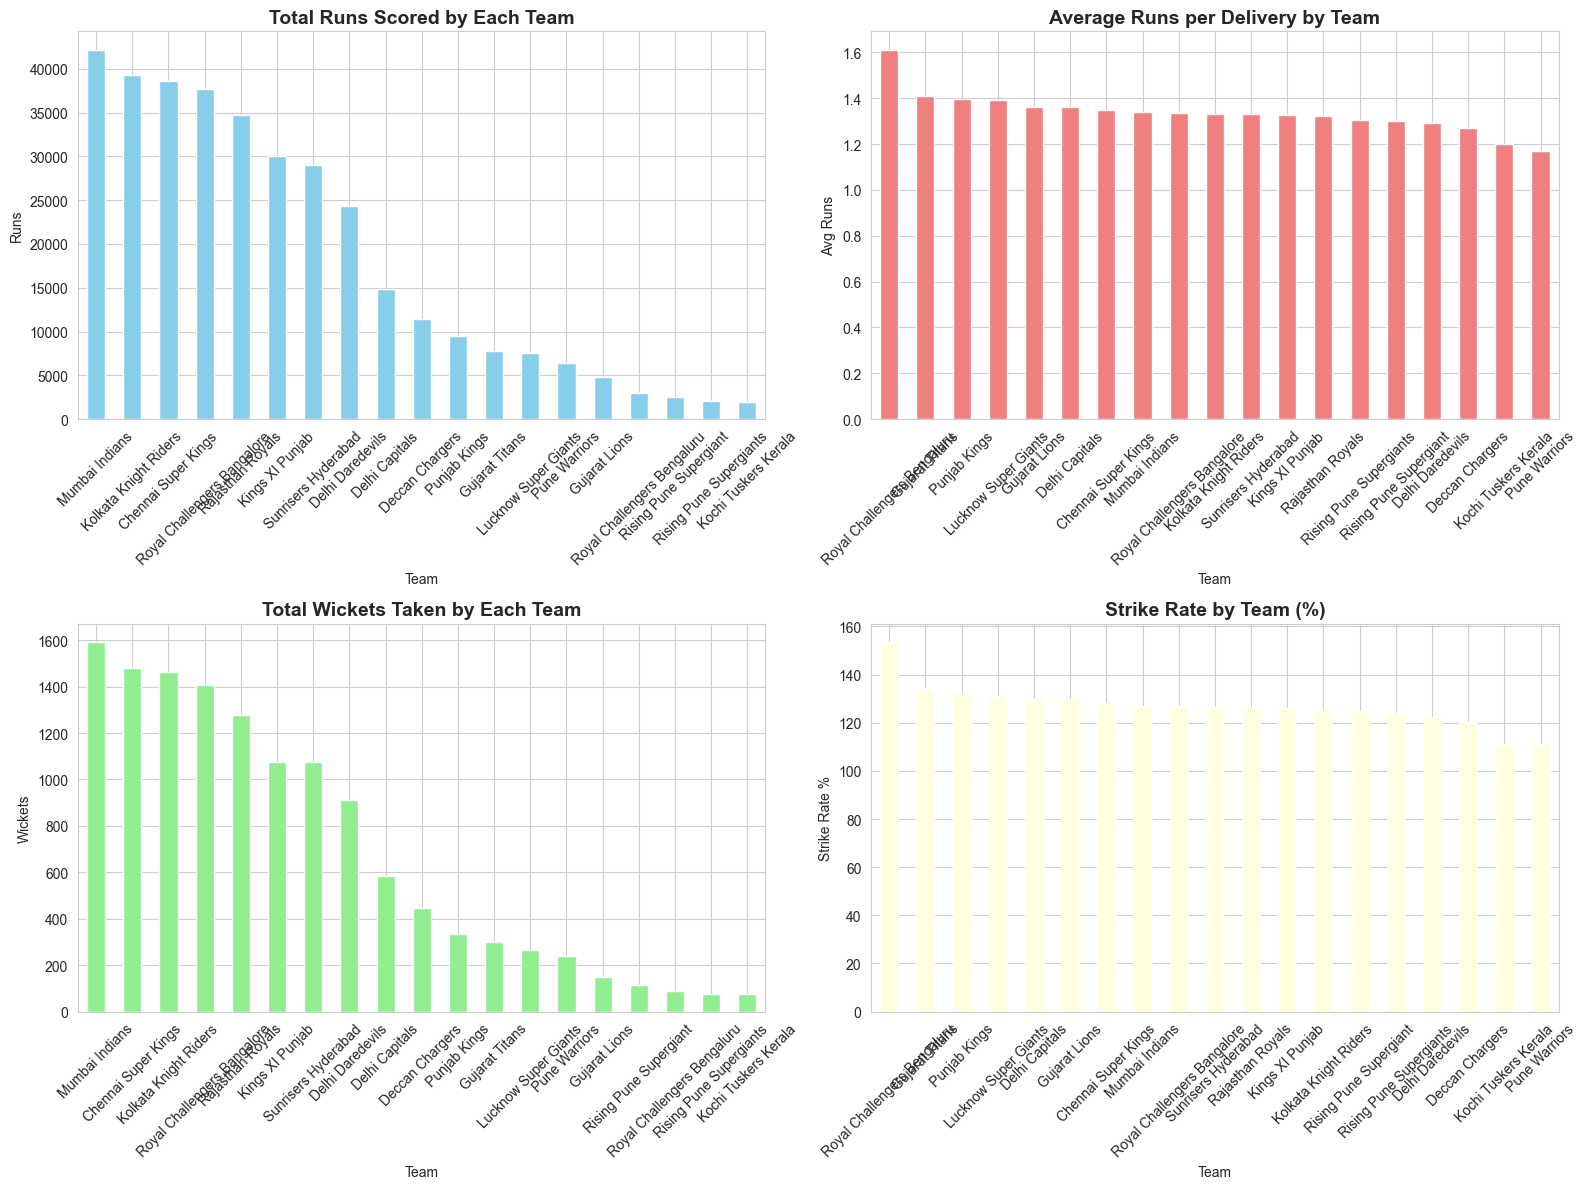

Visualizations created successfully!


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create subplots for venue-based insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total runs by batting team
team_runs.plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Total Runs Scored by Each Team', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Team')
axes[0, 0].set_ylabel('Runs')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Average runs per delivery
team_avg_runs.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Runs per Delivery by Team', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Team')
axes[0, 1].set_ylabel('Avg Runs')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Wickets taken by bowling team
team_wickets.plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Total Wickets Taken by Each Team', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Team')
axes[1, 0].set_ylabel('Wickets')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Strike rate comparison
team_strike_rate.plot(kind='bar', ax=axes[1, 1], color='lightyellow')
axes[1, 1].set_title('Strike Rate by Team (%)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Team')
axes[1, 1].set_ylabel('Strike Rate %')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

In [24]:
# Summary insights from venue-based analysis
print("\n" + "="*60)
print("KEY INSIGHTS FROM VENUE ANALYSIS")
print("="*60)

print(f"\n✓ Highest Scoring Team: {team_runs.idxmax()} ({team_runs.max()} runs)")
print(f"✓ Most Dangerous Bowling Team: {team_wickets.idxmax()} ({team_wickets.max()} wickets)")
print(f"✓ Best Strike Rate: {team_strike_rate.idxmax()} ({team_strike_rate.max():.2f}%)")
print(f"✓ Total Matches: {df['match_id'].nunique()}")
print(f"✓ Total Deliveries: {len(df)}")
print(f"✓ Total Wickets: {(df['is_wicket'] == 1).sum()}")

print("\n" + "="*60)
print("NEXT STEPS TO ENHANCE VENUE ANALYSIS:")
print("="*60)
print("1. If you have a 'matches.csv' file with match_id and venue columns,")
print("   we can merge it with this data for explicit venue-based insights.")
print("2. We can then analyze: pitch behavior, home advantage, venue-specific trends")
print("3. Recommend loading matches.csv and merging it with deliveries data.")
print("="*60)


KEY INSIGHTS FROM VENUE ANALYSIS

✓ Highest Scoring Team: Mumbai Indians (42176 runs)
✓ Most Dangerous Bowling Team: Mumbai Indians (1591 wickets)
✓ Best Strike Rate: Royal Challengers Bengaluru (153.41%)
✓ Total Matches: 1095
✓ Total Deliveries: 260920
✓ Total Wickets: 12950

NEXT STEPS TO ENHANCE VENUE ANALYSIS:
1. If you have a 'matches.csv' file with match_id and venue columns,
   we can merge it with this data for explicit venue-based insights.
2. We can then analyze: pitch behavior, home advantage, venue-specific trends
3. Recommend loading matches.csv and merging it with deliveries data.


## Enhanced Venue Analysis (with Match Details)

In [25]:
# Load matches data
matches = pd.read_csv('matches.csv')
print("Matches Data Shape:", matches.shape)
print("\nMatches Columns:")
print(matches.columns.tolist())
print("\nFirst few matches:")
print(matches.head())

Matches Data Shape: (1095, 20)

Matches Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

First few matches:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                  

In [26]:
# Merge deliveries with match information using match_id and id
# Rename 'id' column in matches to 'match_id' for merging
matches_renamed = matches.rename(columns={'id': 'match_id'})

# Merge datasets
df_merged = df.merge(matches_renamed, on='match_id', how='left')

print("Merged Dataset Shape:", df_merged.shape)
print("\nVenue Information Available:")
print(f"Unique venues: {df_merged['venue'].nunique()}")
print(f"Venues: {df_merged['venue'].unique()[:10]}")
print("\nMerged data sample:")
print(df_merged[['match_id', 'batting_team', 'bowling_team', 'venue', 'total_runs', 'is_wicket']].head())

Merged Dataset Shape: (260920, 36)

Venue Information Available:
Unique venues: 58
Venues: <StringArray>
[                     'M Chinnaswamy Stadium',
 'Punjab Cricket Association Stadium, Mohali',
                           'Feroz Shah Kotla',
                           'Wankhede Stadium',
                               'Eden Gardens',
                     'Sawai Mansingh Stadium',
  'Rajiv Gandhi International Stadium, Uppal',
            'MA Chidambaram Stadium, Chepauk',
                 'Dr DY Patil Sports Academy',
                                   'Newlands']
Length: 10, dtype: str

Merged data sample:
   match_id           batting_team                 bowling_team  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
2    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
3    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
4    335982  Kolkata Knight Riders  Royal Chal